In [25]:
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pyvisa
from IPython.display import display, clear_output

# ---- user config ----
SAVE_DIR      = Path("scope_data")     # where to dump CSVs
CHANNELS      = [1, 2]                 # which channels to read
DURATION_S    = 60                    # total acquisition time
INTERVAL_S    = 1                    # time between acquisitions
POINTS        = 1000                   # samples per trace (max 2500 for TDS)
# ----------------------

SAVE_DIR.mkdir(exist_ok=True)
SESSION_DIR = SAVE_DIR / datetime.now().strftime("session_%Y%m%d_%H%M%S")
SESSION_DIR.mkdir()
print("Saving to:", SESSION_DIR)

Saving to: scope_data\session_20260917_185955


In [26]:
rm = pyvisa.ResourceManager()
print("Available resources:")
for r in rm.list_resources():
    print("  ", r)

# Edit this to match your instrument (e.g., GPIB0::1::INSTR or ASRL1::INSTR)
SCOPE_ADDR = rm.list_resources()[0]
scope = rm.open_resource(SCOPE_ADDR)
scope.timeout = 10_000  # ms

print("\nIDN:", scope.query("*IDN?").strip())
scope.write("HEADER OFF")   # TDS: suppress command echo in replies

Available resources:
   USB0::0x0699::0x0363::C102220::INSTR
   ASRL1::INSTR
   ASRL10::INSTR

IDN: TEKTRONIX,TDS 1002B,C102220,CF:91.1CT FV:v22.11


12

In [27]:
def read_waveform(scope, channel, points=POINTS):
    """Return (time_s, volts) for one channel on a Tektronix TDS scope."""
    # --- select source and configure binary transfer ---
    scope.write(f"DATA:SOURCE CH{channel}")
    scope.write("DATA:ENC RPB")      # RPB = positive binary, fastest for TDS
    scope.write("DATA:WIDTH 1")      # 1 byte per point (8-bit)
    scope.write(f"DATA:STOP {points}")

    # --- preamble: scaling factors (TDS-family SCPI) ---
    ymult = float(scope.query("WFMPRE:YMULT?"))
    yoff  = float(scope.query("WFMPRE:YOFF?"))
    yzero = float(scope.query("WFMPRE:YZERO?"))
    xincr = float(scope.query("WFMPRE:XINCR?"))
    xzero = float(scope.query("WFMPRE:XZERO?"))

    # --- transfer raw binary data ---
    raw = scope.query_binary_values("CURVE?", datatype='b', is_big_endian=True,
                                    container=np.array)

    # TDS scaling formula (from programmer manual)
    volts = (raw.astype(float) - yoff) * ymult + yzero
    time_s = xzero + xincr * np.arange(len(volts))
    return time_s, volts

VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.

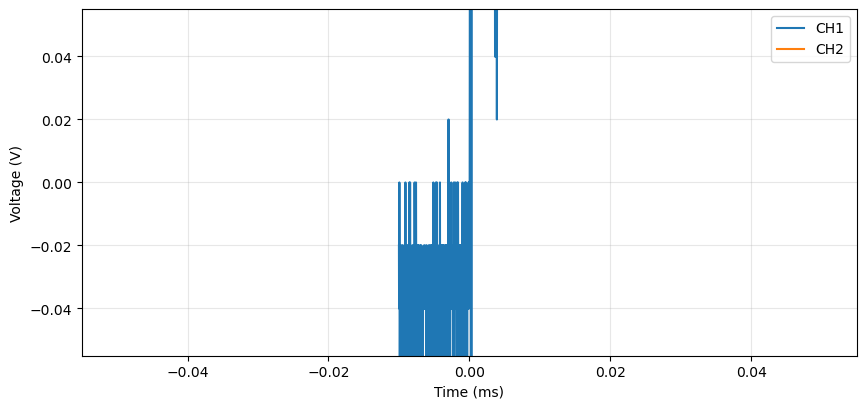

In [29]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 4.5))
lines = {}
for ch in CHANNELS:
    (ln,) = ax.plot([], [], label=f"CH{ch}")
    lines[ch] = ln
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (V)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

t_start = time.monotonic()
n_acq = 0

try:
    while time.monotonic() - t_start < DURATION_S:
        t_now = datetime.now()
        stamp = t_now.strftime("%Y%m%d_%H%M%S_%f")

        for ch in CHANNELS:
            t, v = read_waveform(scope, ch)

            # ---- persist immediately (never lose a trace) ----
            np.savetxt(
                SESSION_DIR / f"ch{ch}_{stamp}.csv",
                np.column_stack([t, v]),
                delimiter=",", header="time_s,voltage_V", comments=""
            )

            lines[ch].set_data(t * 1e3, v)

        ax.relim(); ax.autoscale_view()
        ax.set_title(f"acq #{n_acq:04d}  –  {t_now.strftime('%H:%M:%S')}")

        clear_output(wait=True)
        display(fig)

        n_acq += 1
        time.sleep(INTERVAL_S)

except KeyboardInterrupt:
    print("Stopped by user.")

print(f"\nDone. {n_acq} acquisitions written to {SESSION_DIR}")

In [ ]:
scope.close()
rm.close()